In [8]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model
from xgboost import XGBRegressor

In [49]:
df = pd.read_csv("/content/pakistan_weather_2000_2024.csv")

print(df.head())
print(df.info())

       date  year  month  day  dayofweek  is_weekend  season       city  \
0  1/1/2000  2000      1    1          5           1  Winter  Islamabad   
1  1/2/2000  2000      1    2          6           1  Winter  Islamabad   
2  1/3/2000  2000      1    3          0           0  Winter  Islamabad   
3  1/4/2000  2000      1    4          1           0  Winter  Islamabad   
4  1/5/2000  2000      1    5          2           0  Winter  Islamabad   

   region  latitude  ...  humidity  pressure  dew_point  cloud_cover  \
0  Punjab   33.6844  ...        76    1018.9        4.8            0   
1  Punjab   33.6844  ...        77    1018.6        4.8            0   
2  Punjab   33.6844  ...        76    1016.8        5.0            0   
3  Punjab   33.6844  ...        75    1016.2        4.8            0   
4  Punjab   33.6844  ...        77    1017.5        5.3            0   

   visibility  temp_range  is_hot_day  is_cold_day  rainfall_intensity  \
0         NaN        14.1           0     

In [50]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [51]:
df = df.ffill().bfill() # Forward fill then backward fill to catch leading NaNs
# Fill any remaining NaNs (e.g., if a column was entirely NaN) with 0 for numerical columns
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(0)

In [52]:
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek

In [53]:
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek

In [54]:
cols_to_consider_for_dropna = [col for col in df.columns if col != 'visibility']
df = df.dropna(subset=cols_to_consider_for_dropna)

In [55]:
df = pd.get_dummies(df, drop_first=True)

In [56]:
X = df.drop('tavg', axis=1)
y = df['tavg']


In [57]:
# Convert index to datetime
df.index = pd.to_datetime(df.index)

# Split
train = df[df.index < '2020']
test = df[df.index >= '2020']

# Features & target
X_train = train.drop('tavg', axis=1)
y_train = train['tavg']

X_test = test.drop('tavg', axis=1)
y_test = test['tavg']

# Debug check
print(X_test.shape, y_test.shape)

(5481, 37) (5481,)


In [58]:
print("Full dataset shape:", df.shape)

print("Index type:", type(df.index))
print("Index min:", df.index.min())
print("Index max:", df.index.max())

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Full dataset shape: (31779, 38)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index min: 2000-01-01 00:00:00
Index max: 2024-12-31 00:00:00
Train shape: (26298, 38)
Test shape: (5481, 38)
X_test shape: (5481, 37)
y_test shape: (5481,)


In [59]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (26298, 37)
Shape of X_test: (5481, 37)
Shape of y_train: (26298,)
Shape of y_test: (5481,)


In [60]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [61]:
y_pred = model.predict(X_test)

In [62]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.3340556130526851
RMSE: 0.4319371151731996


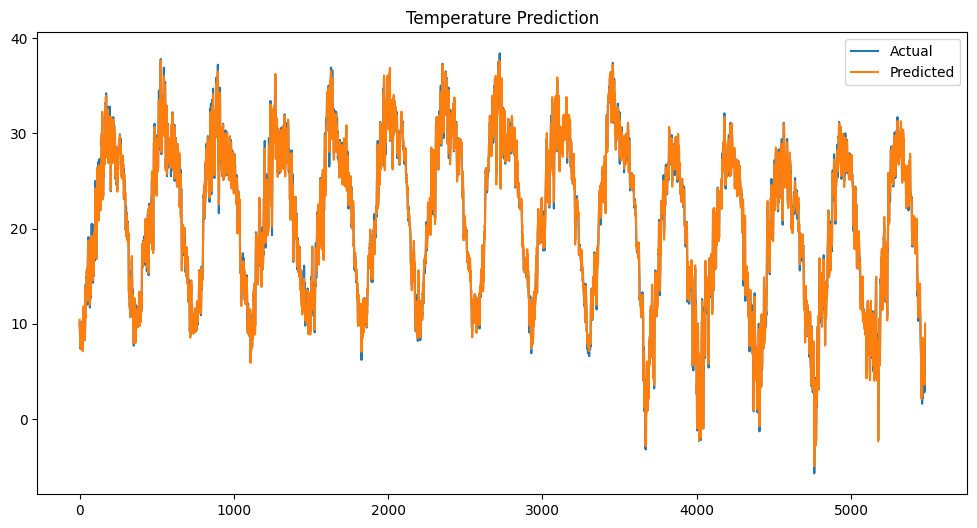

In [63]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Temperature Prediction")
plt.show()

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.3340556130526851
RMSE: 0.4319371151731996
R2 Score: 0.9972622833743009


In [66]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.9991441224281973
Test R2: 0.9972622833743009


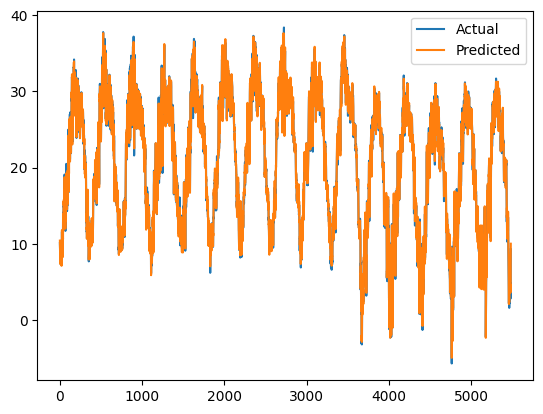

In [67]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

In [68]:
import joblib

joblib.dump(model, "temperature_model.pkl")

['temperature_model.pkl']

In [69]:
from google.colab import files

files.download("temperature_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>